<a href="https://colab.research.google.com/github/kasiaqn/bee-audio-classifier/blob/main/BeehiveProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

In [2]:
# Konfiguracja
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/BeehiveProject'
DRIVE_DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(DRIVE_DATA_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
# Pobranie danych
DATASET_ID = "annajyang/beehive-sounds"
zip_on_drive = os.path.join(DRIVE_DATA_DIR, "beehive-sounds.zip")

if not os.path.exists(zip_on_drive):

    # Połączenie z Kaggle
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    import kaggle

    print("Pobieranie datasetu na Dysk Google.")
    !kaggle datasets download -d {DATASET_ID} -p {DRIVE_DATA_DIR}
    print("Pobieranie zakończone :)")
else:
    print("Plik .zip już jest na Twoim Dysku Google :)")

Plik .zip już jest na Twoim Dysku Google :)


In [4]:
# Kopiowanie z Dysku Google na lokalny dysk sesji + rozpakowywanie
import shutil

local_zip = "/content/temp_beehive.zip"
LOCAL_DATA_PATH = "/content/dataset_local"

if not os.path.exists(local_zip):
    print("Kopiowanie plików na dysk sesji")
    shutil.copy(zip_on_drive, local_zip)

if not os.path.exists(LOCAL_DATA_PATH):
    print("Rozpakowywanie")
    !unzip -q {local_zip} -d {LOCAL_DATA_PATH}
    os.remove(local_zip)
    print("Gotowe, dane są w folderze /content/dataset_local")

Kopiowanie plików na dysk sesji
Rozpakowywanie
Gotowe, dane są w folderze /content/dataset_local


Przykładowy plik:


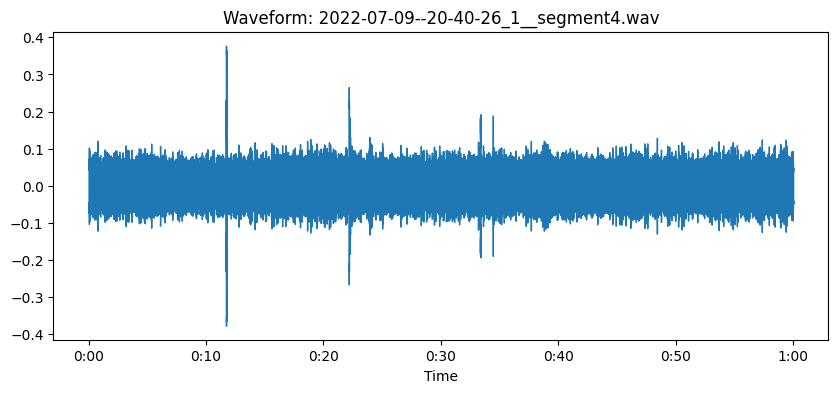

In [5]:
# Wyświetlanie przykładowej fali dźwiękowej
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("Przykładowy plik:")

all_wavs = []
for root, dirs, files in os.walk(LOCAL_DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            all_wavs.append(os.path.join(root, file))

sample_file = all_wavs[0]
y, sr = librosa.load(sample_file, sr=None)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform: {os.path.basename(sample_file)}")
plt.show()

In [6]:
# Eksploracja danych
import pandas as pd

csv_path = os.path.join(LOCAL_DATA_PATH, 'all_data_updated.csv')

df = pd.read_csv(csv_path)
df.head()

,device,hive number,date,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,wind speed,...,rain,lat,long,file name,queen presence,queen acceptance,frames,target,time,queen status
0,1,5,2022-06-08 14:52:28,36.42,30.29,1007.45,26.68,52,1013,8.75,...,0,37.29,-121.95,2022-06-08--14-52-28_1.raw,1,2,8,0,0.583,0
1,1,5,2022-06-08 15:51:41,33.56,33.98,1006.93,25.99,53,1012,10.29,...,0,37.29,-121.95,2022-06-08--15-51-41_1.raw,1,2,8,0,0.625,0
2,1,5,2022-06-08 17:21:53,29.01,42.73,1006.68,24.49,56,1012,8.75,...,0,37.29,-121.95,2022-06-08--17-21-53_1.raw,0,0,8,1,0.708,1
3,1,5,2022-06-08 18:20:59,30.51,36.74,1006.68,22.97,59,1012,8.23,...,0,37.29,-121.95,2022-06-08--18-20-59_1.raw,0,0,8,1,0.750,1
4,1,5,2022-06-08 19:20:04,30.32,35.55,1006.58,21.52,61,1012,7.20,...,0,37.29,-121.95,2022-06-08--19-20-04_1.raw,0,0,8,1,0.792,1


In [11]:
print(df.columns)

Index(['device', 'hive number', 'date', 'hive temp', 'hive humidity',
       'hive pressure', 'weather temp', 'weather humidity', 'weather pressure',
       'wind speed', 'gust speed', 'weatherID', 'cloud coverage', 'rain',
       'lat', 'long', 'file name', 'queen presence', 'queen acceptance',
       'frames', 'target', 'time', 'queen status'],
      dtype='object')


In [31]:
print(len(df))

1275


| Wartość | Status królowej (Queen Status) | Opis / Znaczenie |
| :---: | :--- | :--- |
| **0** | `original queen` | W ulu znajduje się pierwotna królowa |
| **1** | `not present` | Brak królowej w ulu |
| **2** | `present and rejected` | Wprowadzono nową królową, ale została ona odrzucona przez pszczoły |
| **3** | `present and newly accepted` | Nowa królowa została wprowadzona i zaakceptowana przez pszczoły |

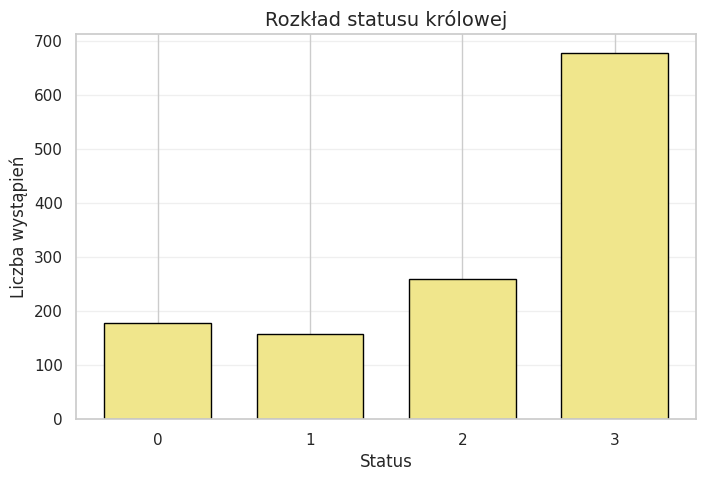

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['queen status'],
         bins=[0, 1, 2, 3, 4],
         align='left',
         color='khaki',
         edgecolor='black',
         rwidth=0.7)

plt.title('Rozkład statusu królowej', fontsize=14)
plt.xticks([0, 1, 2, 3])
plt.xlabel('Status')
plt.ylabel('Liczba wystąpień')
plt.grid(axis='y', alpha=0.3)

plt.show()